# Quantum Phase Estimation: Noise Sensitivity Analysis
**Course module: AyushDocs-NoiseAnalysis**

In this notebook, we move from the ideal simulator and investigate the effects of **quantum noise** on the performance of the QPE algorithm. Modern quantum processors are Noisy Intermediate-Scale Quantum (NISQ) devices, meaning they are prone to gate errors, decoherence, and measurement (readout) errors.

---

## 1. Modeling Quantum Noise

We will model two main sources of noise that affect QPE circuits:
1. **Depolarizing Noise**: This represents the loss of quantum information. For a single-qubit gate, it replaces the qubit state with the maximally mixed state with probability $p_1$. For a two-qubit gate (like the controlled-phase gates in QPE), the state is depolarized with probability $p_2$ (typically an order of magnitude higher than $p_1$).
2. **Readout (Measurement) Noise**: This represents classical mismeasurement. With a small probability (e.g. 2%), a qubit in the state $|0\rangle$ is measured as $1$, and a qubit in the state $|1\rangle$ is measured as $0$.

As we increase the number of ancilla qubits, we gain finer phase resolution but also require deeper circuits with more control gates. The cumulative noise can degrade the precision, creating a critical trade-off between resolution and error.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFTGate
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError

## 2. Implementing Noisy Simulation Pipeline

In [2]:
def qpe_phase_gate(theta, num_ancilla):
    n = num_ancilla
    qc = QuantumCircuit(n + 1, n)
    target = n
    ancillas = list(range(n))
    qc.x(target)
    qc.h(ancillas)
    for j in range(n):
        qc.cp(2**j * theta, ancillas[j], target)
    qc.compose(QFTGate(n).inverse(), ancillas, inplace=True)
    qc.measure(ancillas, list(range(n)))
    return qc

def build_noise(p_depol_1q=1e-4, p_depol_2q=1e-3):
    """
    Builds a Qiskit NoiseModel with depolarizing and readout errors.
    """
    model = NoiseModel()
    # 1-qubit depolarizing error
    model.add_all_qubit_quantum_error(
        depolarizing_error(p_depol_1q, 1), ["u1", "u2", "u3", "h", "x", "p"]
    )
    # 2-qubit depolarizing error (applied to controlled phase gate)
    model.add_all_qubit_quantum_error(
        depolarizing_error(p_depol_2q, 2), ["cp", "cx", "cz"]
    )
    # Readout error (symmetric 2% error rate)
    model.add_all_qubit_readout_error(
        ReadoutError([[0.98, 0.02], [0.02, 0.98]])
    )
    return model

def run_qpe_noisy(theta, num_ancilla, noise_model=None, shots=20000):
    qc = qpe_phase_gate(theta, num_ancilla)
    sim = AerSimulator(noise_model=noise_model) if noise_model else AerSimulator()
    qct = transpile(qc, sim)
    counts = sim.run(qct, shots=shots).result().get_counts()
    total = sum(counts.values())

    phase_est = 0.0
    for bits, c in counts.items():
        frac = sum(int(bits[i]) / (1 << (i + 1)) for i in range(len(bits)))
        phase_est += frac * c / total

    true_phase = (theta % (2 * np.pi)) / (2 * np.pi)
    raw_err = abs(phase_est - true_phase)
    error = min(raw_err, 1.0 - raw_err)
    return phase_est, error, counts

## 3. Sweeping Noise Rates

In [3]:
def sweep_noise(theta, num_ancilla, rates, shots=10000):
    # Get ideal error reference
    _, ideal_err, _ = run_qpe_noisy(theta, num_ancilla, noise_model=None, shots=shots)
    noisy_errs = []
    for r in rates:
        # 2-qubit depolarizing error is assumed to be 10x the 1-qubit error rate
        model = build_noise(r, r * 10)
        _, err, _ = run_qpe_noisy(theta, num_ancilla, model, shots)
        noisy_errs.append(err)
    return rates, noisy_errs, ideal_err

## 4. Plotting and Comparing Noisy vs. Ideal QPE

In [4]:
def plot_noise(rates, noisy_errs, ideal_err, save=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.semilogy(rates, noisy_errs, "ro-", ms=7, label="With hardware-like noise")
    ax.axhline(ideal_err, color="b", ls="--", lw=2, label="Ideal simulator")
    ax.set_xlabel("1-qubit depolarising rate")
    ax.set_ylabel("Phase estimation error")
    ax.set_title("QPE: Ideal Simulator vs Noisy Hardware Model")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=150)
        print(f"Saved noise comparison plot to {save}")
    plt.show()

## 5. Execution and Analysis

Let's choose $n=6$ ancillas and sweep the single-qubit depolarizing rate from $10^{-5}$ to $10^{-2}$.

  1Q Depol Rate | Measured Error
---------------------------------
          Ideal |       2.70e-03
       1.00e-05 |       5.92e-03
       5.00e-05 |       6.74e-03
       1.00e-04 |       5.15e-03
       5.00e-04 |       8.77e-03
       1.00e-03 |       1.85e-02
       5.00e-03 |       4.33e-02
       1.00e-02 |       6.52e-02


Saved noise comparison plot to ../docs/noise_comparison.png


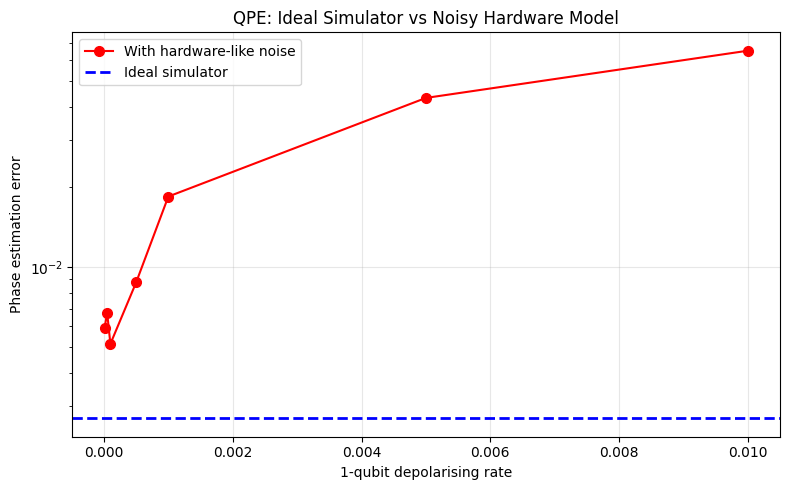

In [5]:
THETA = 2 * np.pi * 0.4
rates = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2]

r_vals, n_errs, ideal = sweep_noise(THETA, 6, rates, 10000)

print(f"{'1Q Depol Rate':>15} | {'Measured Error':>14}")
print("-" * 33)
print(f"{'Ideal':>15} | {ideal:14.2e}")
for r, e in zip(r_vals, n_errs):
    print(f"{r:15.2e} | {e:14.2e}")

plot_noise(r_vals, n_errs, ideal, "../docs/noise_comparison.png")

### Discussion
As expected, when the gate depolarizing rate increases, the phase estimation error rises. Readout error and gate errors introduce random fluctuations that disrupt the phase coherent kickback, which makes the peaks in our measurement probability distribution broader and flatter. To mitigate this in practical hardware, we need quantum error correction or error mitigation techniques.